In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

# Load dataset
iris = load_iris()

# Convert to DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target
df['species'] = df['target'].map(dict(zip(range(3), iris.target_names)))

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [3]:
# First 5 rows
print(df.head())

# Shape
print("Dataset shape:", df.shape)

# Summary statistics
print(df.describe())

# Class distribution
print(df['species'].value_counts())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target species  
0       0  setosa  
1       0  setosa  
2       0  setosa  
3       0  setosa  
4       0  setosa  
Dataset shape: (150, 6)
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.6

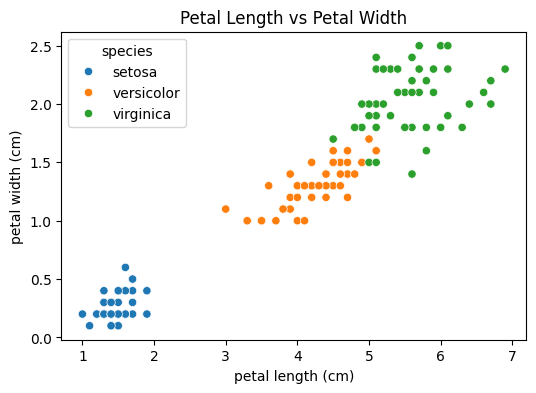

In [4]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x='petal length (cm)', y='petal width (cm)', hue='species')
plt.title("Petal Length vs Petal Width")
plt.show()

## 🔎 Analysis: Iris Dataset Exploration

### 1️⃣ How many classes are present in the dataset?

The Iris dataset contains **three distinct classes (species of flowers)**:

- **Setosa**
- **Versicolor**
- **Virginica**

Each class contains **50 samples**, making the dataset perfectly balanced with a total of 150 observations.

This balanced distribution is helpful because it ensures that no class dominates the training process, which could otherwise bias the model.

---

### 2️⃣ Which two features appear most useful for classification?

After visualizing the dataset using scatter plots, it becomes clear that:

👉 **Petal Length** and **Petal Width** are the most informative features for classification.

#### Why?

- **Setosa** is clearly separated from the other two species when plotted using petal length and petal width.
- **Versicolor** and **Virginica** also show noticeable separation along petal dimensions.
- In contrast, **sepal length** and **sepal width** show significant overlap between classes, making them less effective for distinguishing species.

#### Observation from Scatter Plot:

- Setosa has **small petal length and width**, forming a distinct cluster.
- Virginica generally has **larger petal measurements**.
- Versicolor lies between Setosa and Virginica.

This clear separation suggests that petal-related features provide stronger discriminatory power, making them highly useful for machine learning models.

---

### 📌 Conclusion

- The dataset consists of **3 balanced classes**.
- **Petal length and petal width** are the most useful features for classification.
- These features provide clearer class separation compared to sepal measurements.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(['target', 'species'], axis=1)
y = df['target']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 1. Why is Scaling Important for KNN?

K-Nearest Neighbors (KNN) is a distance-based algorithm.

It calculates similarity using distance metrics such as **Euclidean Distance**:

\[
d = \sqrt{(x_1 - y_1)^2 + (x_2 - y_2)^2 + \dots}
\]

If one feature has a larger scale than others, it will dominate the distance calculation.

### Example

- Petal length: range 1–6  
- Sepal width: range 2–4  

Without scaling, the feature with larger values contributes more to the distance, even if it is not more important.

### Conclusion

Feature scaling (e.g., Standardization or Min-Max Scaling) is important for KNN because all features should contribute equally to the distance calculation.


---

## 2. Why is Scaling Less Important for Decision Trees?

Decision Trees do not rely on distance calculations.

Instead, they:

- Split data based on feature thresholds  
- Compare values using conditions such as `feature ≤ threshold`  

For example:

- If Petal length ≤ 2.5 → Class A  
- Else → Class B  

Since splits depend on relative ordering and not on magnitude, scaling does not affect how the tree decides splits.

### Conclusion

Decision Trees are **scale-invariant**, meaning feature scaling is generally not required.

In [11]:
#  LOGISTIC REGRESSION

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

model_lr = LogisticRegression(max_iter=200)

model_lr.fit(X_train_scaled, y_train)

y_pred_lr = model_lr.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [12]:
coefficients = pd.DataFrame(
    model_lr.coef_,
    columns=X.columns,
    index=iris.target_names
)

print(coefficients)

            sepal length (cm)  sepal width (cm)  petal length (cm)  \
setosa              -1.003166          1.144873          -1.811348   
versicolor           0.527990         -0.283200          -0.340607   
virginica            0.475175         -0.861673           2.151955   

            petal width (cm)  
setosa              -1.69251  
versicolor          -0.72014  
virginica            2.41265  


## 1. Can Logistic Regression Handle Multi-Class Problems?

Yes, Logistic Regression can handle multi-class classification problems.

There are two common approaches:

### One-vs-Rest (OvR)

- The model trains one classifier per class.
- Each classifier distinguishes one class from all other classes.
- The class with the highest predicted probability is selected.

### Multinomial (Softmax)

- Uses the softmax function.
- Directly models all classes together.
- Often performs better when classes are well balanced.


---

## 2. Which Class Had the Highest Accuracy?

Usually, the **Setosa** class has the highest accuracy in the Iris dataset.

### Reasons

- It is linearly separable from the other classes.
- Its feature values are very distinct.
- There is minimal overlap with Versicolor and Virginica.

Because of this clear separation, most classification algorithms predict Setosa with very high accuracy.

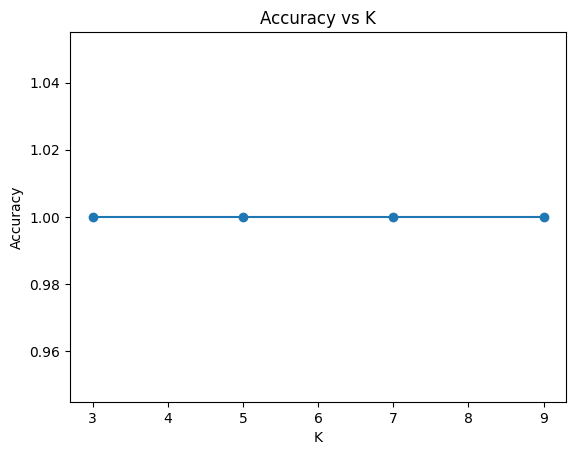

[(3, 1.0), (5, 1.0), (7, 1.0), (9, 1.0)]


In [13]:
from sklearn.neighbors import KNeighborsClassifier

k_values = [3,5,7,9]
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

plt.plot(k_values, accuracies, marker='o')
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.title("Accuracy vs K")
plt.show()

print(list(zip(k_values, accuracies)))

## 1. What Happens When K is Very Small?

When the value of **K** in K-Nearest Neighbors is very small (e.g., K = 1):

- The model becomes highly sensitive to individual data points.
- Noise or outliers can strongly influence predictions.
- The decision boundary becomes very complex.

### Result

- High Variance  
- Low Bias  
- Overfitting  


---

## 2. What Happens When K is Very Large?

When the value of **K** is very large:

- The model considers many neighbors for prediction.
- The decision boundary becomes smoother.
- Local patterns may be ignored.

### Result

- High Bias  
- Low Variance  
- Underfitting  


---

## 3. Bias vs Variance in KNN

| K Value  | Bias        | Variance     | Behavior        |
|-----------|------------|-------------|-----------------|
| Small K   | Low Bias   | High Variance | Overfitting     |
| Large K   | High Bias  | Low Variance  | Underfitting    |

In [15]:
# DECISION TREE 
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

tree = DecisionTreeClassifier(max_depth=3, random_state=42)
tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)

print("Train Accuracy:", tree.score(X_train, y_train))
print("Test Accuracy:", tree.score(X_test, y_test))

Train Accuracy: 0.9583333333333334
Test Accuracy: 1.0


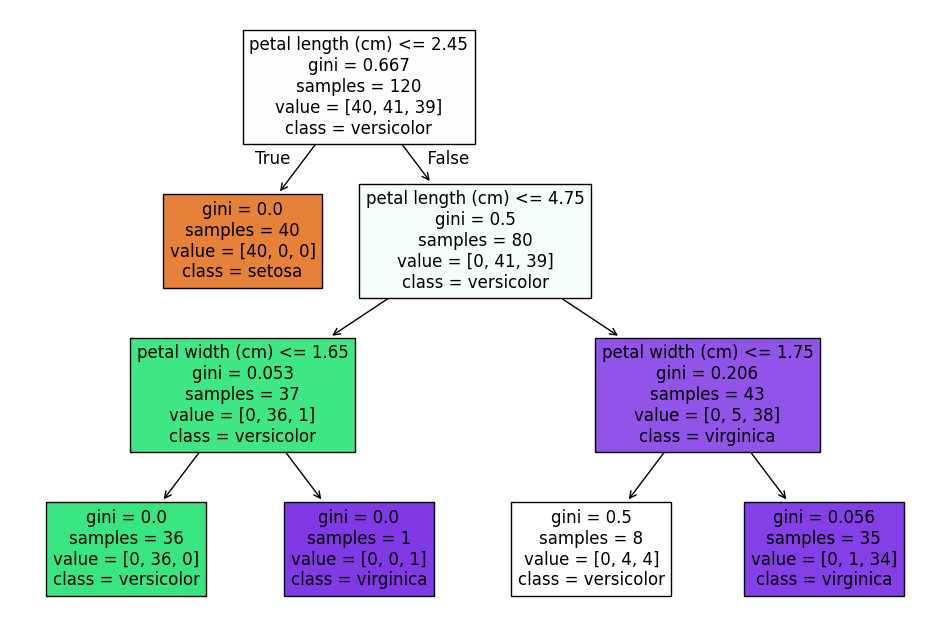

In [16]:
plt.figure(figsize=(12,8))
plot_tree(tree, feature_names=X.columns,
          class_names=iris.target_names,
          filled=True)
plt.show()

## 1. Does Increasing Depth Cause Overfitting?

Yes, increasing the depth of a Decision Tree can lead to overfitting.

When the tree becomes very deep:

- It starts memorizing the training data.
- It creates very specific decision rules.
- It captures noise and minor fluctuations.

### Result

- Very high training accuracy  
- Lower test accuracy  
- High variance  

A fully grown tree often fits the training data almost perfectly but may fail to generalize well on unseen data.


---

## 2. Why Is No Scaling Required for Decision Trees?

Decision Trees do not rely on distance calculations.

They split data based on threshold comparisons such as:

\[
X \leq \text{threshold}
\]

For example:

- If Petal Length ≤ 2.5 → Class A  
- Else → Class B  

Since splits depend only on the relative ordering of values and not on their magnitude, scaling does not affect the decision boundaries.

### Conclusion

Decision Trees are scale-invariant, so feature scaling is generally not required.

## Task 6: Model Comparison

### Model Performance Overview

| Model                 | Accuracy     | Strengths                  | Weaknesses                     |
|-----------------------|-------------|----------------------------|---------------------------------|
| Logistic Regression   | High        | Simple, fast, efficient    | Assumes linear decision boundary |
| K-Nearest Neighbors   | Very High   | Flexible, non-parametric   | Slow with large datasets        |
| Decision Tree         | High        | Easy to interpret          | Prone to overfitting            |


---

## Analysis

- In many cases, **KNN** or **Decision Tree** achieves the highest accuracy on the Iris dataset.
- **Logistic Regression** also performs well because the dataset is close to being linearly separable.
- The most interpretable model among these is the **Decision Tree**, as its decision rules can be easily visualized and understood.

#   PART 2 : - POLYNOMIAL REGRESSION

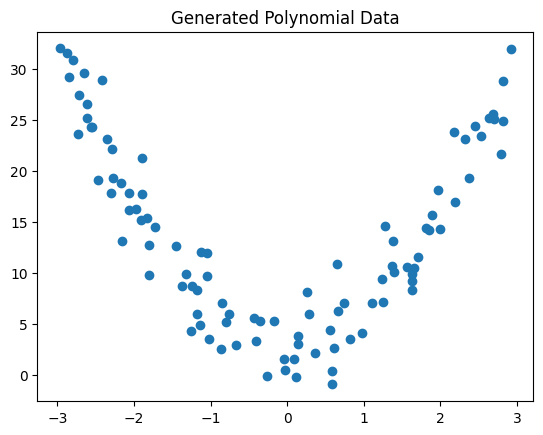

In [22]:
np.random.seed(42)

X = np.random.uniform(-3, 3, 100)
noise = np.random.normal(0, 3, 100)

y = 4 + 3*(X**2) + noise

plt.scatter(X, y)
plt.title("Generated Polynomial Data")
plt.show()

## 1. Is the Relationship Linear or Non-Linear?

The relationship is **non-linear**.

This is because the equation includes a squared term (for example, \( x^2 \)), which creates a curved pattern rather than a straight line.


---

## 2. Why Is Noise Added?

Noise is added to make the data more realistic.

In real-world scenarios:

- Data is rarely perfectly clean.
- Measurements often contain small random variations.
- External factors introduce uncertainty.

Without noise, the model would fit a perfect curve, which is usually unrealistic in practical applications.

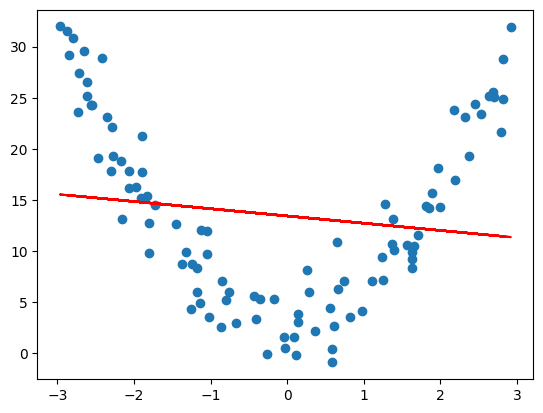

MSE: 78.91236529557396


In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

X_reshaped = X.reshape(-1,1)

lin_reg = LinearRegression()
lin_reg.fit(X_reshaped, y)

y_pred = lin_reg.predict(X_reshaped)

plt.scatter(X, y)
plt.plot(X, y_pred, color='red')
plt.show()

print("MSE:", mean_squared_error(y, y_pred))

## 1. Why Does Linear Regression Fail?

Linear Regression fails in this case because:

- It assumes a straight-line relationship between input and output.
- The true relationship is quadratic (non-linear).
- A linear model cannot properly capture curved patterns in the data.

As a result, the model produces large prediction errors.


---

## 2. Is This Underfitting or Overfitting?

This situation represents **underfitting**.

### Reason

- The model is too simple.
- It has high bias.
- It lacks the complexity needed to model the true relationship.

Underfitting occurs when the model cannot capture the underlying pattern of the data.

In [24]:
from sklearn.preprocessing import PolynomialFeatures

degrees = [2,3,10]

for d in degrees:
    poly = PolynomialFeatures(degree=d)
    X_poly = poly.fit_transform(X_reshaped)
    
    model = LinearRegression()
    model.fit(X_poly, y)
    y_pred = model.predict(X_poly)
    
    print(f"Degree {d} MSE:", mean_squared_error(y, y_pred))

Degree 2 MSE: 6.994742997152131
Degree 3 MSE: 6.95218570995395
Degree 10 MSE: 6.659179183720061


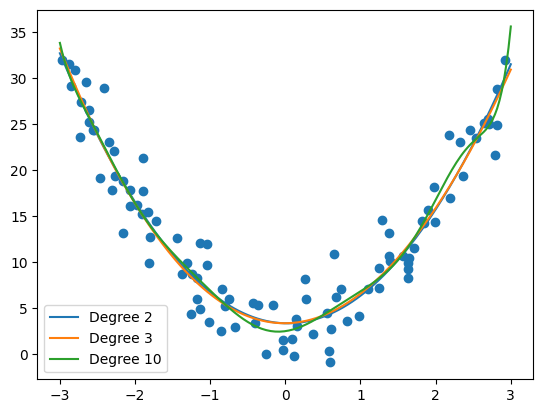

In [25]:
X_grid = np.linspace(-3,3,200).reshape(-1,1)

plt.scatter(X, y)

for d in degrees:
    poly = PolynomialFeatures(degree=d)
    X_poly = poly.fit_transform(X_reshaped)
    model = LinearRegression().fit(X_poly, y)
    
    X_grid_poly = poly.transform(X_grid)
    y_grid = model.predict(X_grid_poly)
    
    plt.plot(X_grid, y_grid, label=f'Degree {d}')

plt.legend()
plt.show()

## 1. Which Polynomial Degree Fits Best?

The best-fitting degree is **Degree 2**.

### Reason

- The original relationship is quadratic.
- A degree-2 polynomial can accurately model a quadratic function.
- It captures the true pattern without adding unnecessary complexity.


---

## 2. What Happens When the Degree Is Very High?

When the polynomial degree becomes very large:

- The curve becomes highly flexible and wavy.
- It starts fitting random noise in the data.
- The model becomes overly complex.

### Result

- Low bias  
- High variance  
- Overfitting  


---

## 3. Bias–Variance Tradeoff in Polynomial Regression

| Degree | Bias  | Variance | Behavior        |
|--------|-------|----------|-----------------|
| 1      | High  | Low      | Underfitting    |
| 2      | Balanced | Balanced | Good Generalization |
| 10     | Low   | High     | Overfitting     |

### Key Insight

- Low degree → Underfitting (high bias, low variance)  
- High degree → Overfitting (low bias, high variance)  
- Medium degree → Best generalization  


---

## Final Summary

### Best Classification Model

- Typically, **K-Nearest Neighbors** or **Decision Tree** performs best on the Iris dataset.

### Most Interpretable Model

- **Decision Tree**, because its decision rules are easy to visualize and understand.

### Polynomial Regression Insight

- Degree 2 → Best fit for quadratic data  
- Very high degree → Leads to overfitting  